# Analysis of different aggregation functions for EIP-8037 (v2)

## Maximizing throughput under ≤ 100 GiB/yr state growth

#### Maria Silva, February 2026



We sweep over a grid of $m$ (repricing multiplier) and $w_s$ (state weight) for each aggregation function. A configuration $(m, w_s, \text{agg})$ is **robustly feasible** if annual state growth $\leq$ 100 GiB for **every** $(\varepsilon_s, \varepsilon_b)$ pair in the uncertainty range. Among robustly feasible configurations, the optimal is the one with the **highest median throughput gain** across all elasticity pairs.

#### Parameters

- $n=5$
- $s=0.23$
- $G^0=60$ (in million gas units)
- $b^0=1$ (in gwei)
- State growth is 325 MiB per day $\implies$ $S^0 = \frac{325 \cdot 1048576 \cdot 12}{60 \cdot 60 \cdot 24}$ bytes
- $\varepsilon_s \in [0.3, 0.6]$
- $\varepsilon_b \in [0, 0.2]$
- $w_r = 1.0$

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [2]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

# output folder
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
src_dir = os.path.join(repo_dir, "src")
our_dir = os.path.join(repo_dir, "reports", "figures", "8037_agg_funs_report_v2")
os.makedirs(our_dir, exist_ok=True)

In [3]:
sys.path.append(src_dir)
import state_growth

### Parameter sweep

In [4]:
# Parameters
n = 5
s = 0.23
G_0 = 60
b_0 = 1.0
S_0 = (325 * 1048576 * 12) / (60 * 60 * 24)
eps_s_values = np.linspace(0.3, 0.6, 5)
eps_b_values = np.linspace(0, 0.2, 5)
w_r = 1.0

# Fine grid
m_fine = np.arange(10, 55, 5)
w_s_fine = np.arange(0.2, 2.2, 0.2)

STATE_GROWTH_CAP = 100  # GiB/yr

fine_results = []

for m in m_fine:
    for w_s in w_s_fine:
        for eps_s in eps_s_values:
            for eps_b in eps_b_values:
                common = dict(m=int(m), w_s=round(float(w_s), 3), eps_s=round(eps_s, 2), eps_b=round(eps_b, 2))
                # --- sum (w_s not used) ---
                b = state_growth.find_equilibrium_base_fee_sum(m, n, eps_s, eps_b, b_0, s)
                r = state_growth.compute_equilibrium_stats(b, m, n, eps_s, eps_b, G_0, b_0, S_0, s)
                r.update(common); r["agg_function"] = "sum"
                fine_results.append(r)
                # --- max (w_s not used) ---
                b = state_growth.find_equilibrium_base_fee_max(m, n, eps_s, eps_b, b_0, s)
                r = state_growth.compute_equilibrium_stats(b, m, n, eps_s, eps_b, G_0, b_0, S_0, s)
                r.update(common); r["agg_function"] = "max"
                fine_results.append(r)
                # --- asymmetric_max ---
                b = state_growth.find_equilibrium_base_fee_asymmetric_max(m, n, eps_s, eps_b, b_0, s, w_s=w_s, w_r=w_r)
                r = state_growth.compute_equilibrium_stats(b, m, n, eps_s, eps_b, G_0, b_0, S_0, s)
                r.update(common); r["agg_function"] = "asymmetric_max"
                fine_results.append(r)
                # --- asymmetric_euclidean ---
                b = state_growth.find_equilibrium_base_fee_asymmetric_euclidean(m, n, eps_s, eps_b, b_0, s, w_s=w_s, w_r=w_r)
                r = state_growth.compute_equilibrium_stats(b, m, n, eps_s, eps_b, G_0, b_0, S_0, s)
                r.update(common); r["agg_function"] = "asymmetric_euclidean"
                fine_results.append(r)

fine_df = pd.DataFrame(fine_results)
fine_df["burst_throughput_gain"] = fine_df["burst_throughput_s"] / (1 - s)
fine_df = fine_df.dropna(subset=["annual_state_growth_gib"])

print(f"Total rows: {len(fine_df)}")
print(f"Rows under {STATE_GROWTH_CAP} GiB/yr: {(fine_df['annual_state_growth_gib'] <= STATE_GROWTH_CAP).sum()}")

Total rows: 9000
Rows under 100 GiB/yr: 5227


### Computing robust feasibility

A configuration $(m, w_s, \text{agg})$ is robustly feasible iff:

$$\max_{\varepsilon_s, \varepsilon_b} \text{StateGrowth}(m, w_s, \text{agg}, \varepsilon_s, \varepsilon_b) \leq 100 \text{ GiB/yr}$$

The objective is:

$$\max_{(m, w_s, \text{agg}) \in \text{feasible}} \; \text{median}_{\varepsilon_s, \varepsilon_b} \; \text{ThroughputGain}(m, w_s, \text{agg}, \varepsilon_s, \varepsilon_b)$$

In [5]:
n_elasticity_combos = len(eps_s_values) * len(eps_b_values)

robust_summary = (
    fine_df
    .groupby(["m", "w_s", "agg_function"])
    .agg(
        max_state_growth=("annual_state_growth_gib", "max"),
        min_state_growth=("annual_state_growth_gib", "min"),
        median_throughput=("burst_throughput_gain", "median"),
        min_throughput=("burst_throughput_gain", "min"),
        max_throughput=("burst_throughput_gain", "max"),
        count=("burst_throughput_gain", "count"),
    )
    .reset_index()
)

# Robustly feasible = ALL elasticity combos under the cap
robust_summary["robust_feasible"] = (
    (robust_summary["max_state_growth"] <= STATE_GROWTH_CAP)
    & (robust_summary["count"] == n_elasticity_combos)
)

robust_feasible = robust_summary[robust_summary["robust_feasible"]].copy()

# Shared variables for plots
agg_order = ["sum", "max", "asymmetric_max", "asymmetric_euclidean"]
palette = sns.color_palette("Set2")
color_map = dict(zip(agg_order, palette))

print(f"Total configurations: {len(robust_summary)}")
print(f"Robustly feasible (≤ {STATE_GROWTH_CAP} GiB/yr for all elasticities): {len(robust_feasible)}")
print(f"\nRobustly feasible configs per aggregation function:")
print(robust_feasible.groupby("agg_function").size().to_string())

Total configurations: 360
Robustly feasible (≤ 100 GiB/yr for all elasticities): 205

Robustly feasible configs per aggregation function:
agg_function
asymmetric_euclidean    48
asymmetric_max          47
max                     50
sum                     60


### Best robust configuration per aggregation function

For each aggregation function, the optimal configuration has the highest **median** throughput gain across all elasticity pairs, subject to **all** pairs being under the state growth cap.

Note: for `sum` and `max`, the weight $w_s$ has no effect (shown for completeness).

In [6]:
best_robust = (
    robust_feasible
    .sort_values("median_throughput", ascending=False)
    .groupby("agg_function")
    .first()
    .reset_index()
    [["agg_function", "m", "w_s"]]
)
best_robust["is_best_robust"] = True
optimal_detail = fine_df.merge(best_robust, on=["agg_function", "m", "w_s"], how="left")
optimal_detail["is_best_robust"] = optimal_detail["is_best_robust"].fillna(False)
optimal_detail = optimal_detail[optimal_detail["is_best_robust"]]


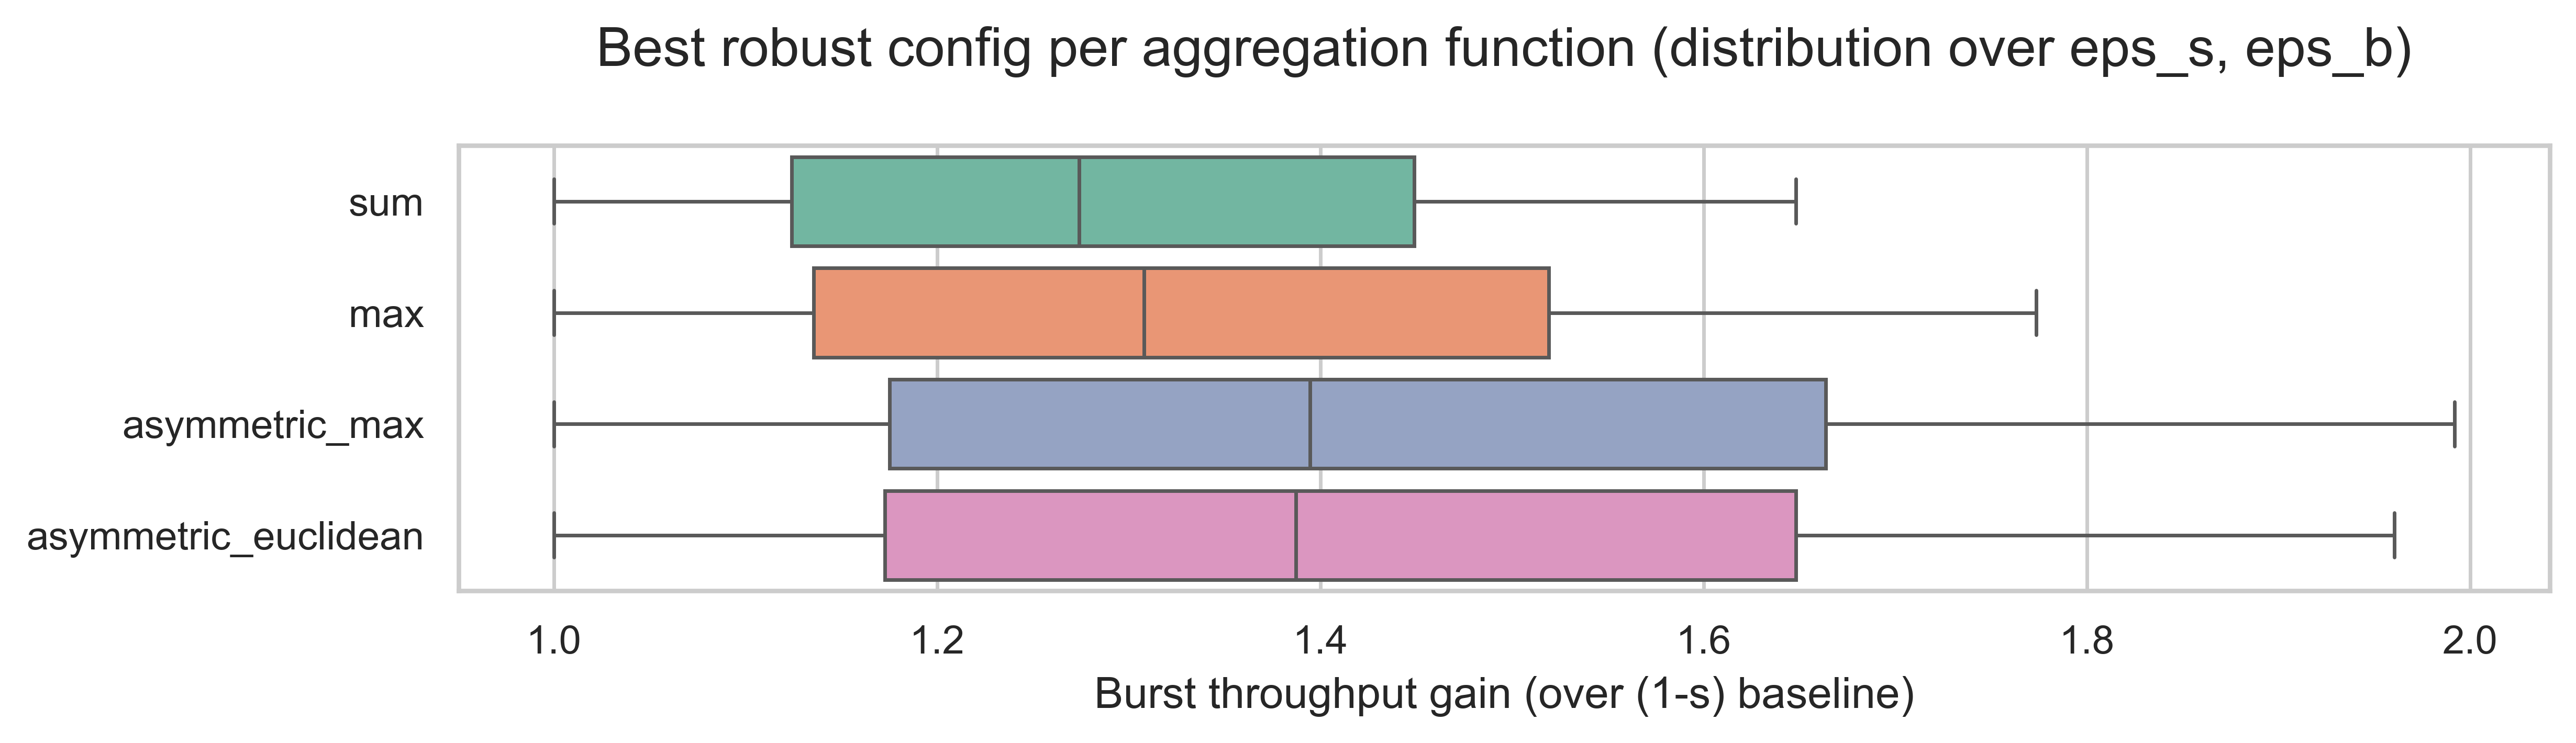

In [7]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=optimal_detail,
    y="agg_function",
    x="burst_throughput_gain",
    hue="agg_function"
)
plt.ylabel("")
plt.xlabel("Burst throughput gain (over (1-s) baseline)")
plt.title("Best robust config per aggregation function (distribution over eps_s, eps_b)\n")
plt.tight_layout()
our_file = os.path.join(our_dir, "robust_best_per_agg_throughput.png")
plt.savefig(our_file, bbox_inches="tight", dpi=144)
plt.show()

In [8]:
optimal_detail.groupby("agg_function")["burst_throughput_gain"].describe()

,count,mean,std,min,25%,50%,75%,max
agg_function,,,,,,,,
asymmetric_euclidean,25.0,1.415091,0.325000,1.0,1.172604,1.387239,1.648008,1.960428
asymmetric_max,25.0,1.428592,0.338752,1.0,1.175198,1.394458,1.663757,1.991905
max,25.0,1.325575,0.254648,1.0,1.135548,1.308061,1.519157,1.773364
sum,25.0,1.276479,0.208845,1.0,1.124080,1.274163,1.448842,1.648062


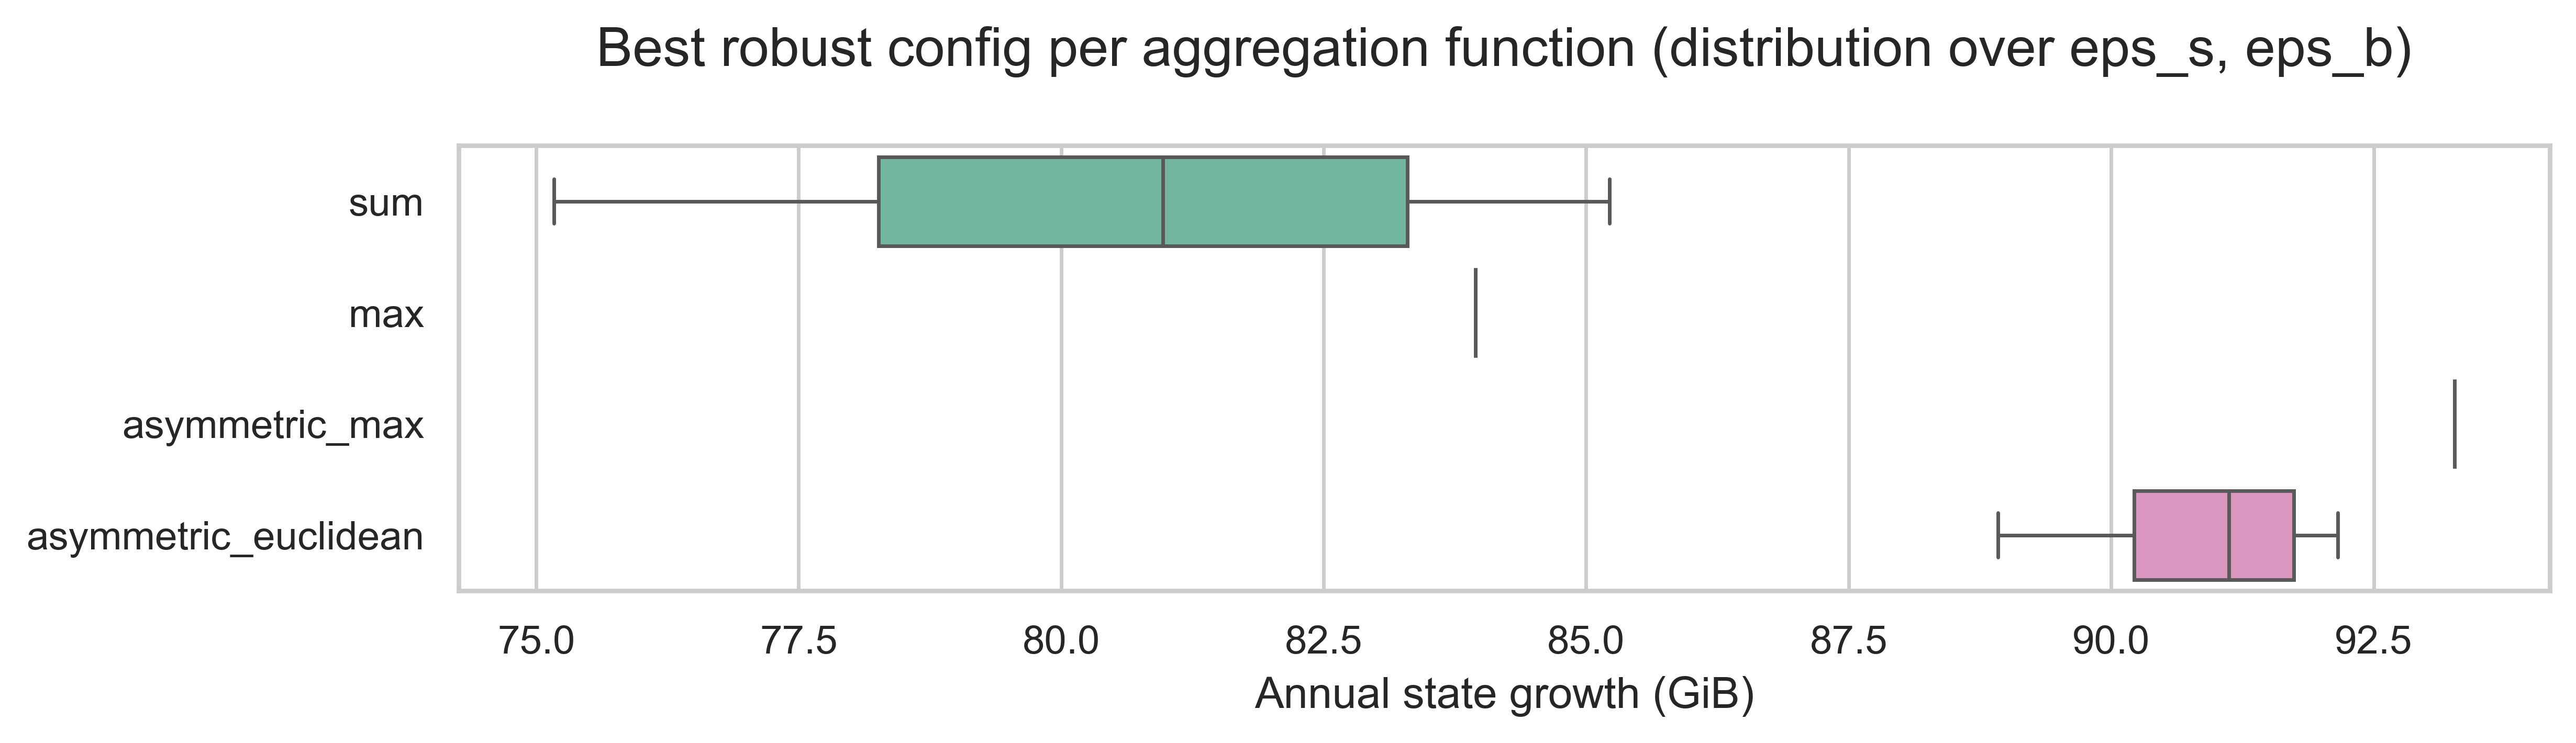

In [9]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=optimal_detail,
    y="agg_function",
    x="annual_state_growth_gib",
    hue="agg_function"
)
plt.ylabel("")
plt.xlabel("Annual state growth (GiB)")
plt.title("Best robust config per aggregation function (distribution over eps_s, eps_b)\n")
plt.tight_layout()
plt.show()

In [10]:
optimal_detail.groupby("agg_function")["annual_state_growth_gib"].describe()

,count,mean,std,min,25%,50%,75%,max
agg_function,,,,,,,,
asymmetric_euclidean,25.0,90.909844,1.079694e+00,88.920409,90.218838,91.119394,91.739335,92.160062
asymmetric_max,25.0,93.272727,2.751920e-14,93.272727,93.272727,93.272727,93.272727,93.272727
max,25.0,83.945454,2.246933e-14,83.945454,83.945454,83.945454,83.945454,83.945454
sum,25.0,80.932377,3.239844e+00,75.167963,78.258485,80.968308,83.296562,85.221425


In [11]:
optimal_detail.groupby("agg_function")["share_state"].describe()

,count,mean,std,min,25%,50%,75%,max
agg_function,,,,,,,,
asymmetric_euclidean,25.0,1.624445,1.929278e-02,1.588896,1.612098,1.628189,1.639267,1.646785
asymmetric_max,25.0,1.666667,4.532467e-16,1.666667,1.666667,1.666667,1.666667,1.666667
max,25.0,1.000000,1.433292e-16,1.000000,1.000000,1.000000,1.000000,1.000000
sum,25.0,0.803422,3.216219e-02,0.746198,0.776878,0.803779,0.826892,0.846000


In [12]:
optimal_detail.groupby("agg_function")["share_burst"].describe()

,count,mean,std,min,25%,50%,75%,max
agg_function,,,,,,,,
asymmetric_euclidean,25.0,0.217924,0.050050,0.154,0.180581,0.213635,0.253793,0.301906
asymmetric_max,25.0,0.220003,0.052168,0.154,0.180981,0.214746,0.256219,0.306753
max,25.0,0.204138,0.039216,0.154,0.174874,0.201441,0.233950,0.273098
sum,25.0,0.196578,0.032162,0.154,0.173108,0.196221,0.223122,0.253802


### Feasibility landscape for asymmetric aggregation functions

Heatmaps show the median throughput gain for each $(m, w_s)$ pair. Gray cells are infeasible (some $(\varepsilon_s, \varepsilon_b)$ pair exceeds the 100 GiB/yr cap). The red star marks the optimal configuration.

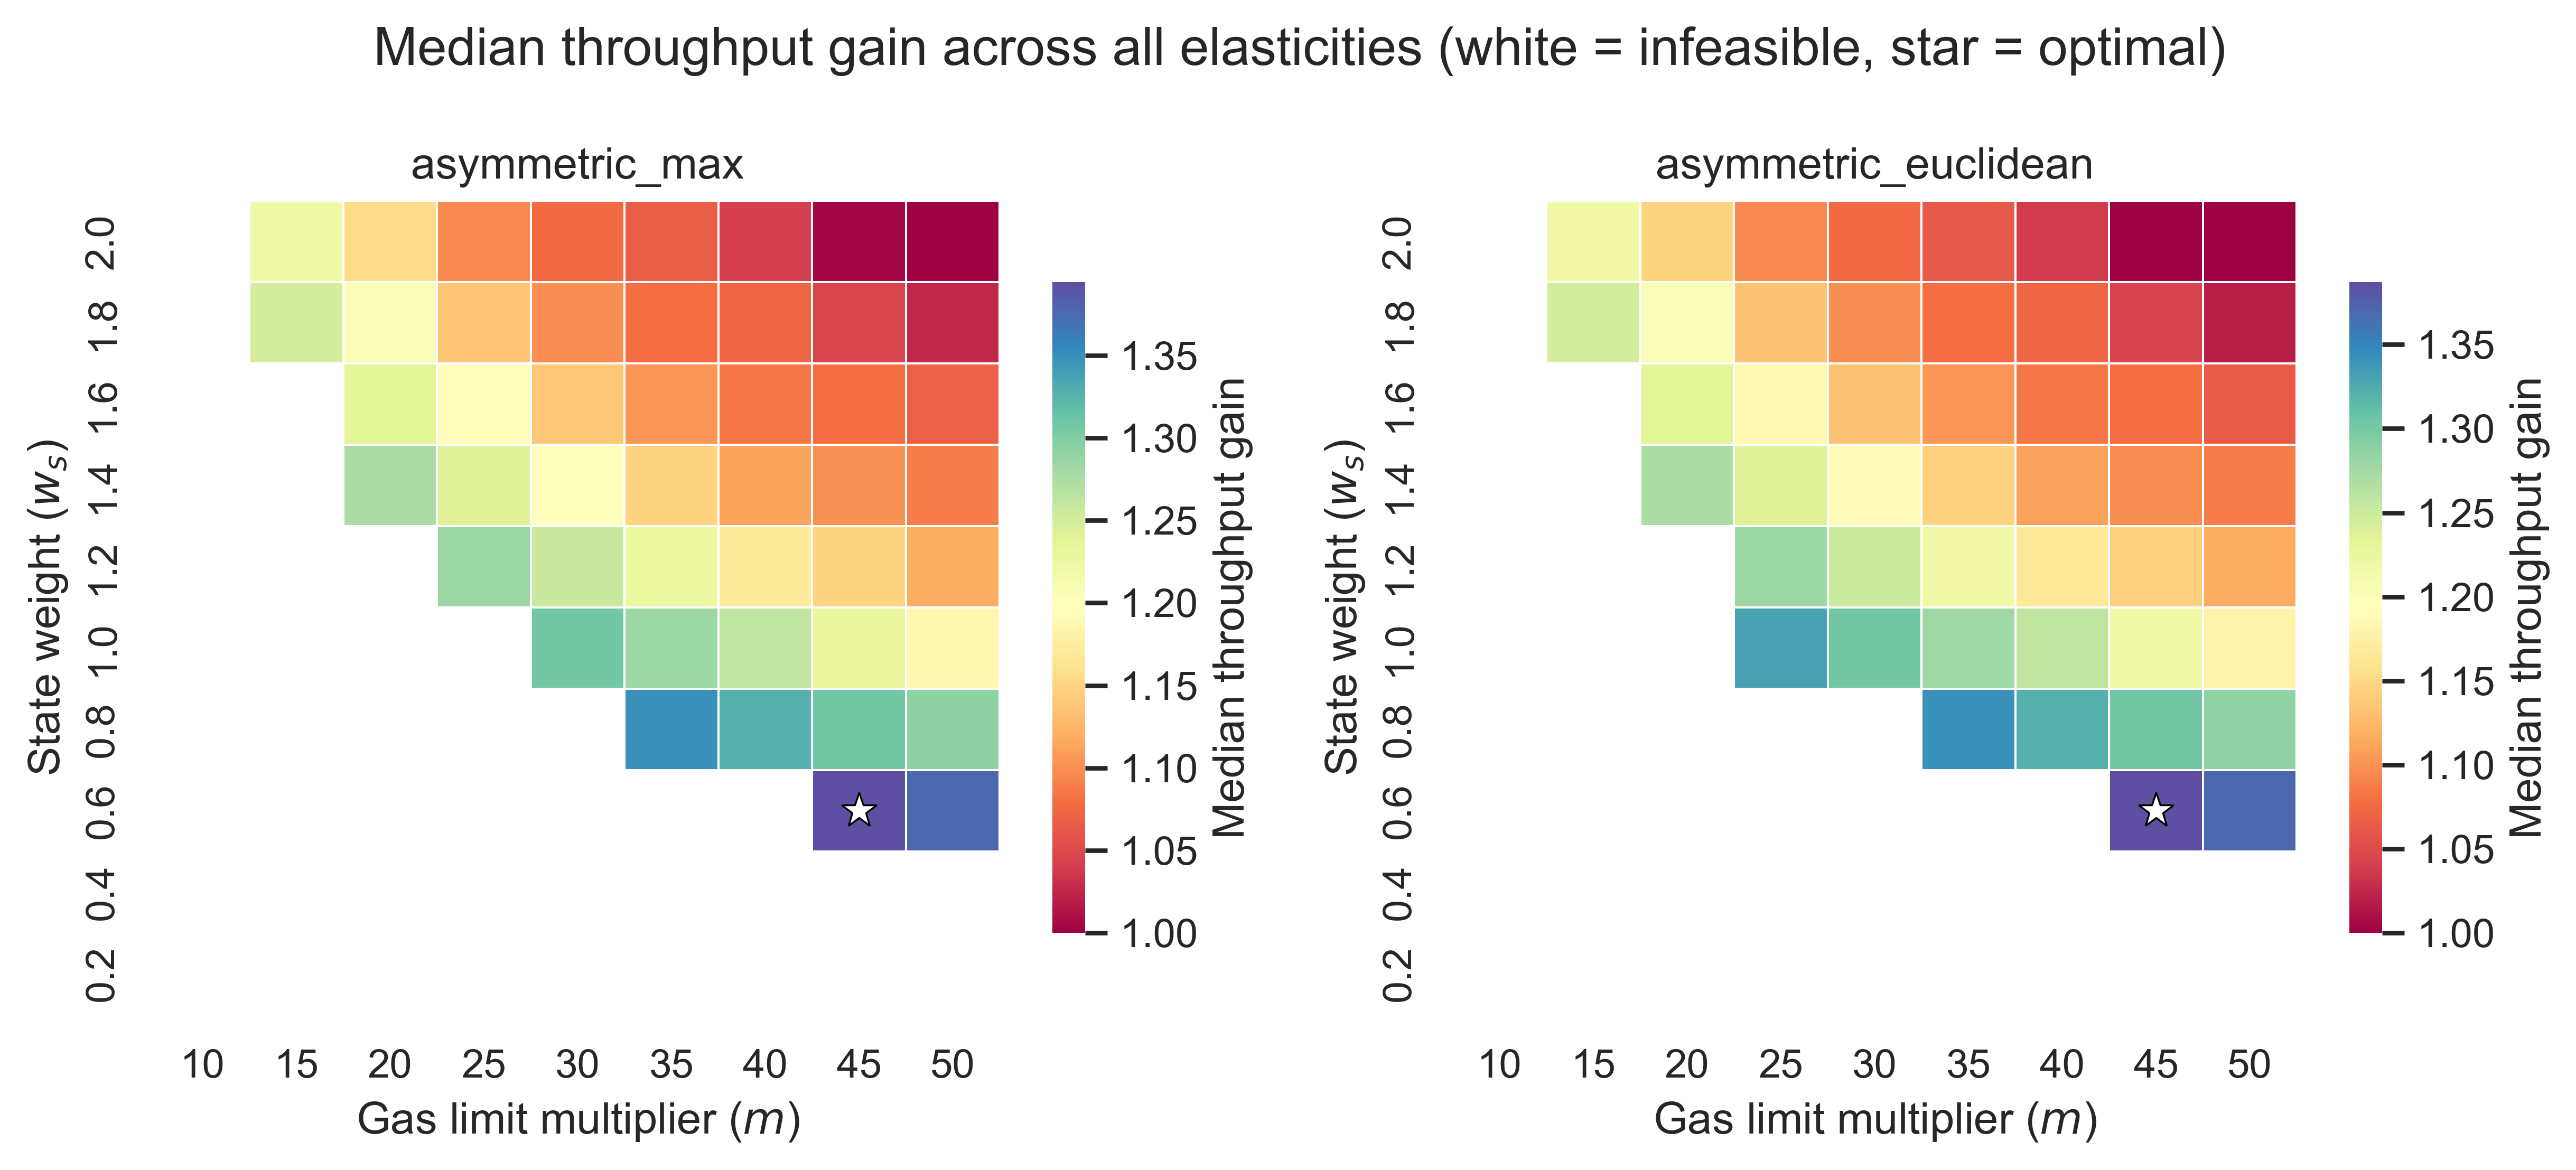

In [13]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for idx, agg in enumerate(["asymmetric_max", "asymmetric_euclidean"]):
    ax = axes[idx]
    sub = robust_summary[robust_summary["agg_function"] == agg].copy()

    pivot_throughput = sub.pivot(index="w_s", columns="m", values="median_throughput")
    pivot_feasible = sub.pivot(index="w_s", columns="m", values="robust_feasible")

    # High w_s at top
    pivot_throughput = pivot_throughput.sort_index(ascending=False)
    pivot_feasible = pivot_feasible.sort_index(ascending=False)

    # Mask infeasible for color scale
    masked = pivot_throughput.copy()
    masked[~pivot_feasible] = np.nan

    sns.heatmap(
        masked,
        ax=ax,
        cmap="Spectral",
        linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Median throughput gain", "shrink": 0.8},
    )

    # Gray overlay for infeasible cells
    for (i, j), feasible in np.ndenumerate(pivot_feasible.values):
        if not feasible:
            ax.add_patch(Rectangle(
                (j, i), 1, 1, facecolor="white", ec="white", lw=0.3
            ))

    # Star on optimal config
    cfg = best_robust[best_robust["agg_function"] == agg].iloc[0]
    m_vals = list(pivot_throughput.columns)
    ws_vals = list(pivot_throughput.index)
    if cfg["m"] in m_vals and cfg["w_s"] in ws_vals:
        jx = m_vals.index(cfg["m"]) + 0.5
        iy = ws_vals.index(cfg["w_s"]) + 0.5
        ax.plot(jx, iy, "*", color="white", markersize=10,
                markeredgecolor="black", markeredgewidth=0.5, zorder=10)

    ax.set_title(agg, fontsize=12)
    ax.set_xlabel("Gas limit multiplier ($m$)")
    ax.set_ylabel("State weight ($w_s$)")

fig.suptitle(
    f"Median throughput gain across all elasticities (white = infeasible, star = optimal)",
)
plt.tight_layout()
our_file = os.path.join(our_dir, "robust_feasibility_landscape.png")
plt.savefig(our_file, bbox_inches="tight", dpi=144)
plt.show()

### Best robust throughput gain by gas limit multiplier $m$

For each $(m, \text{agg\_function})$ pair, we find the $w_s$ that maximizes the median throughput gain while remaining robustly feasible.

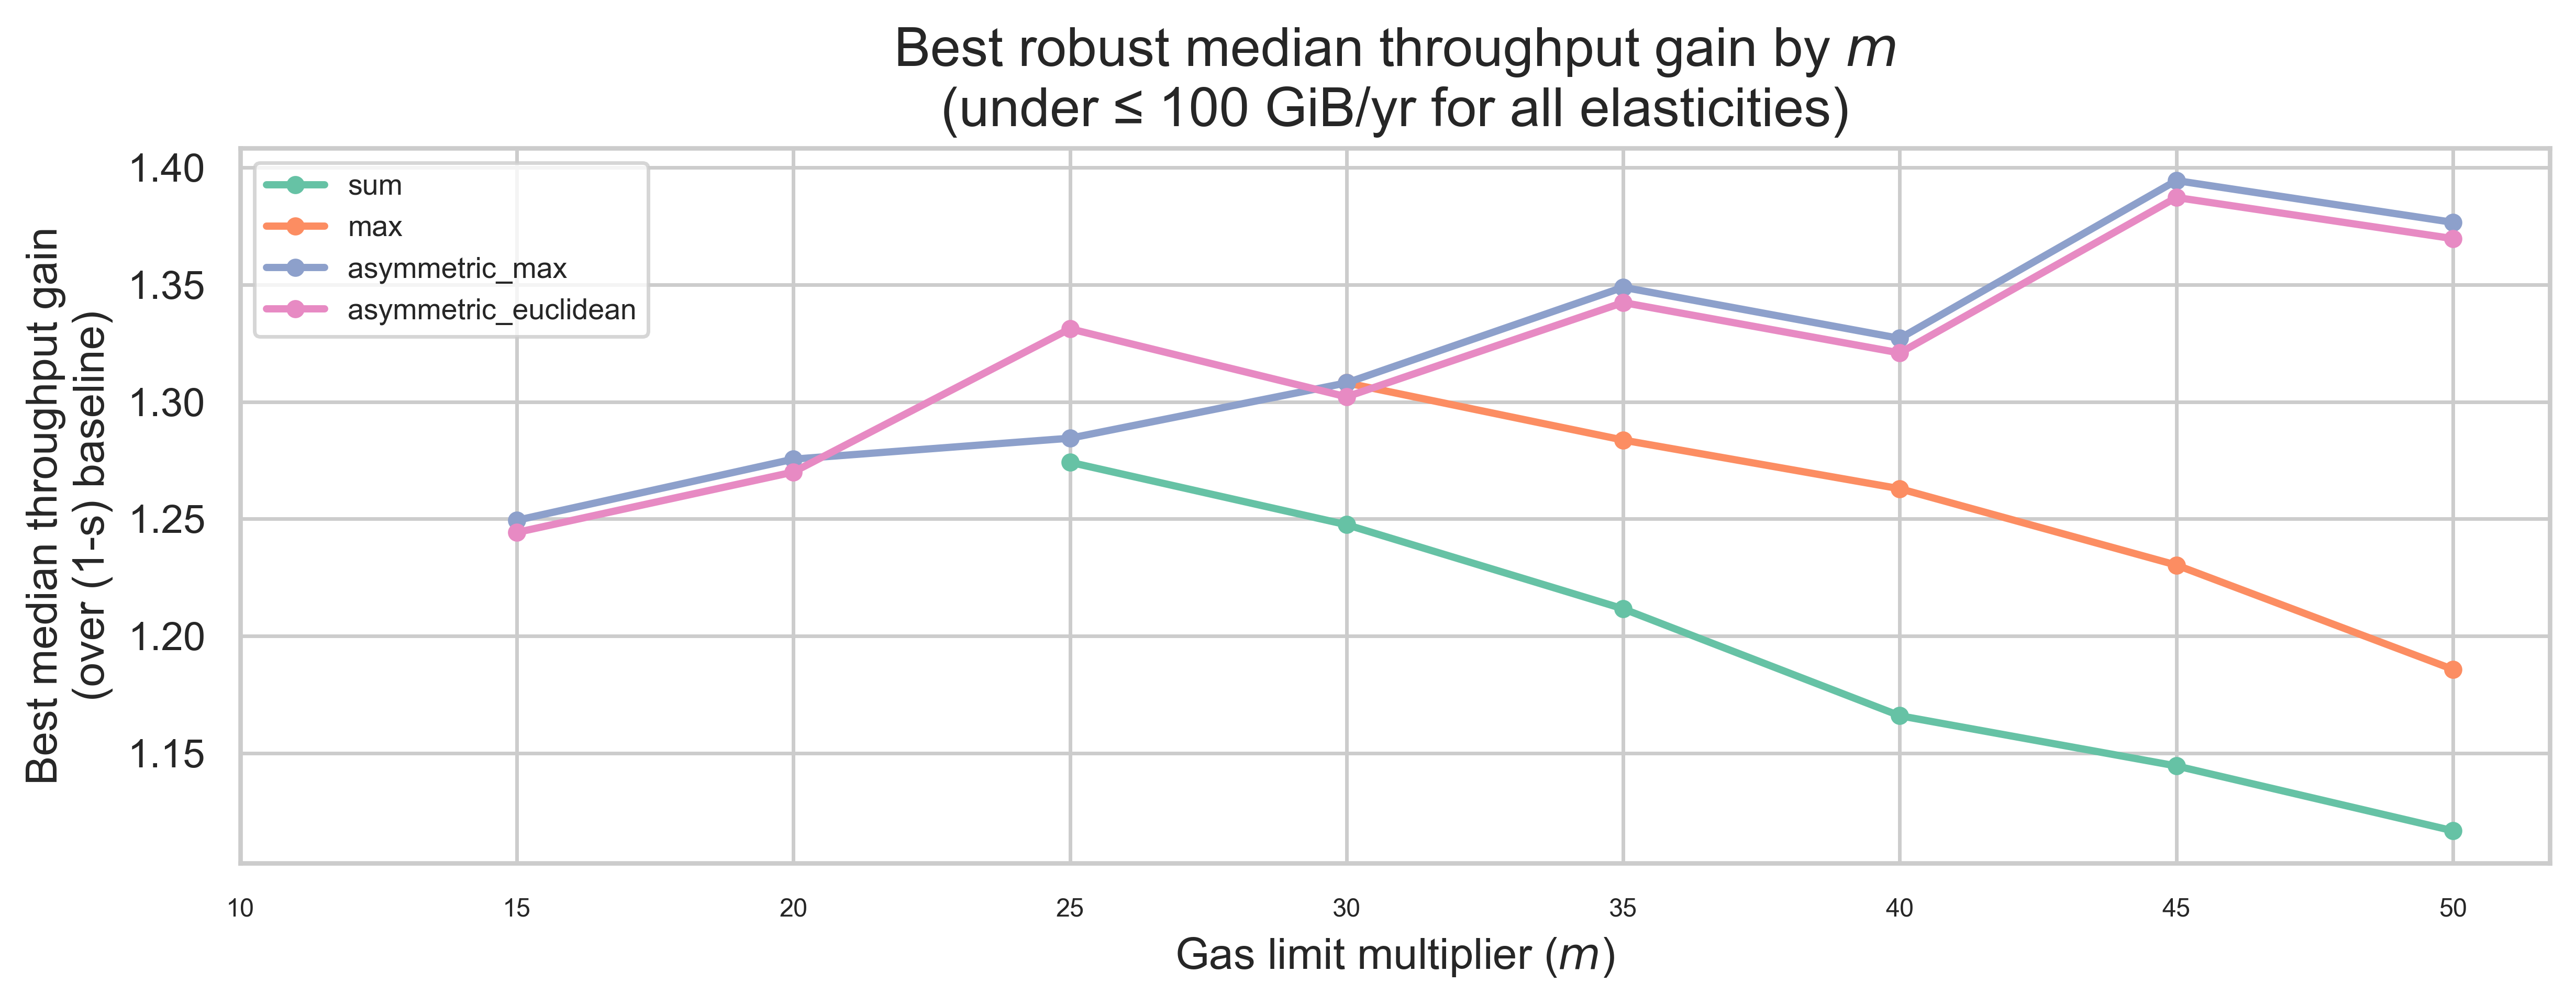

In [14]:
best_by_m_robust = (
    robust_feasible
    .sort_values("median_throughput", ascending=False)
    .groupby(["m", "agg_function"])
    .first()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for agg in agg_order:
    sub = best_by_m_robust[best_by_m_robust["agg_function"] == agg].sort_values("m")
    ax.plot(sub["m"], sub["median_throughput"], marker="o", markersize=4,
            label=agg, color=color_map[agg], linewidth=2)

ax.set_xlabel("Gas limit multiplier ($m$)")
ax.set_ylabel("Best median throughput gain\n(over (1-s) baseline)")
ax.set_title(f"Best robust median throughput gain by $m$\n(under ≤ {STATE_GROWTH_CAP} GiB/yr for all elasticities)")
ax.legend(fontsize=8)
ax.set_xticks(m_fine)
ax.tick_params(axis="x", labelsize=7)
plt.tight_layout()
our_file = os.path.join(our_dir, "robust_best_throughput_by_m.png")
plt.savefig(our_file, bbox_inches="tight", dpi=144)
plt.show()

### Throughput gain and state growth variation across elasticities

For each optimal configuration, we show how throughput gain and state growth vary across the full range of $(\varepsilon_s, \varepsilon_b)$. The box plots show the distribution, while the heatmaps reveal the sensitivity structure.

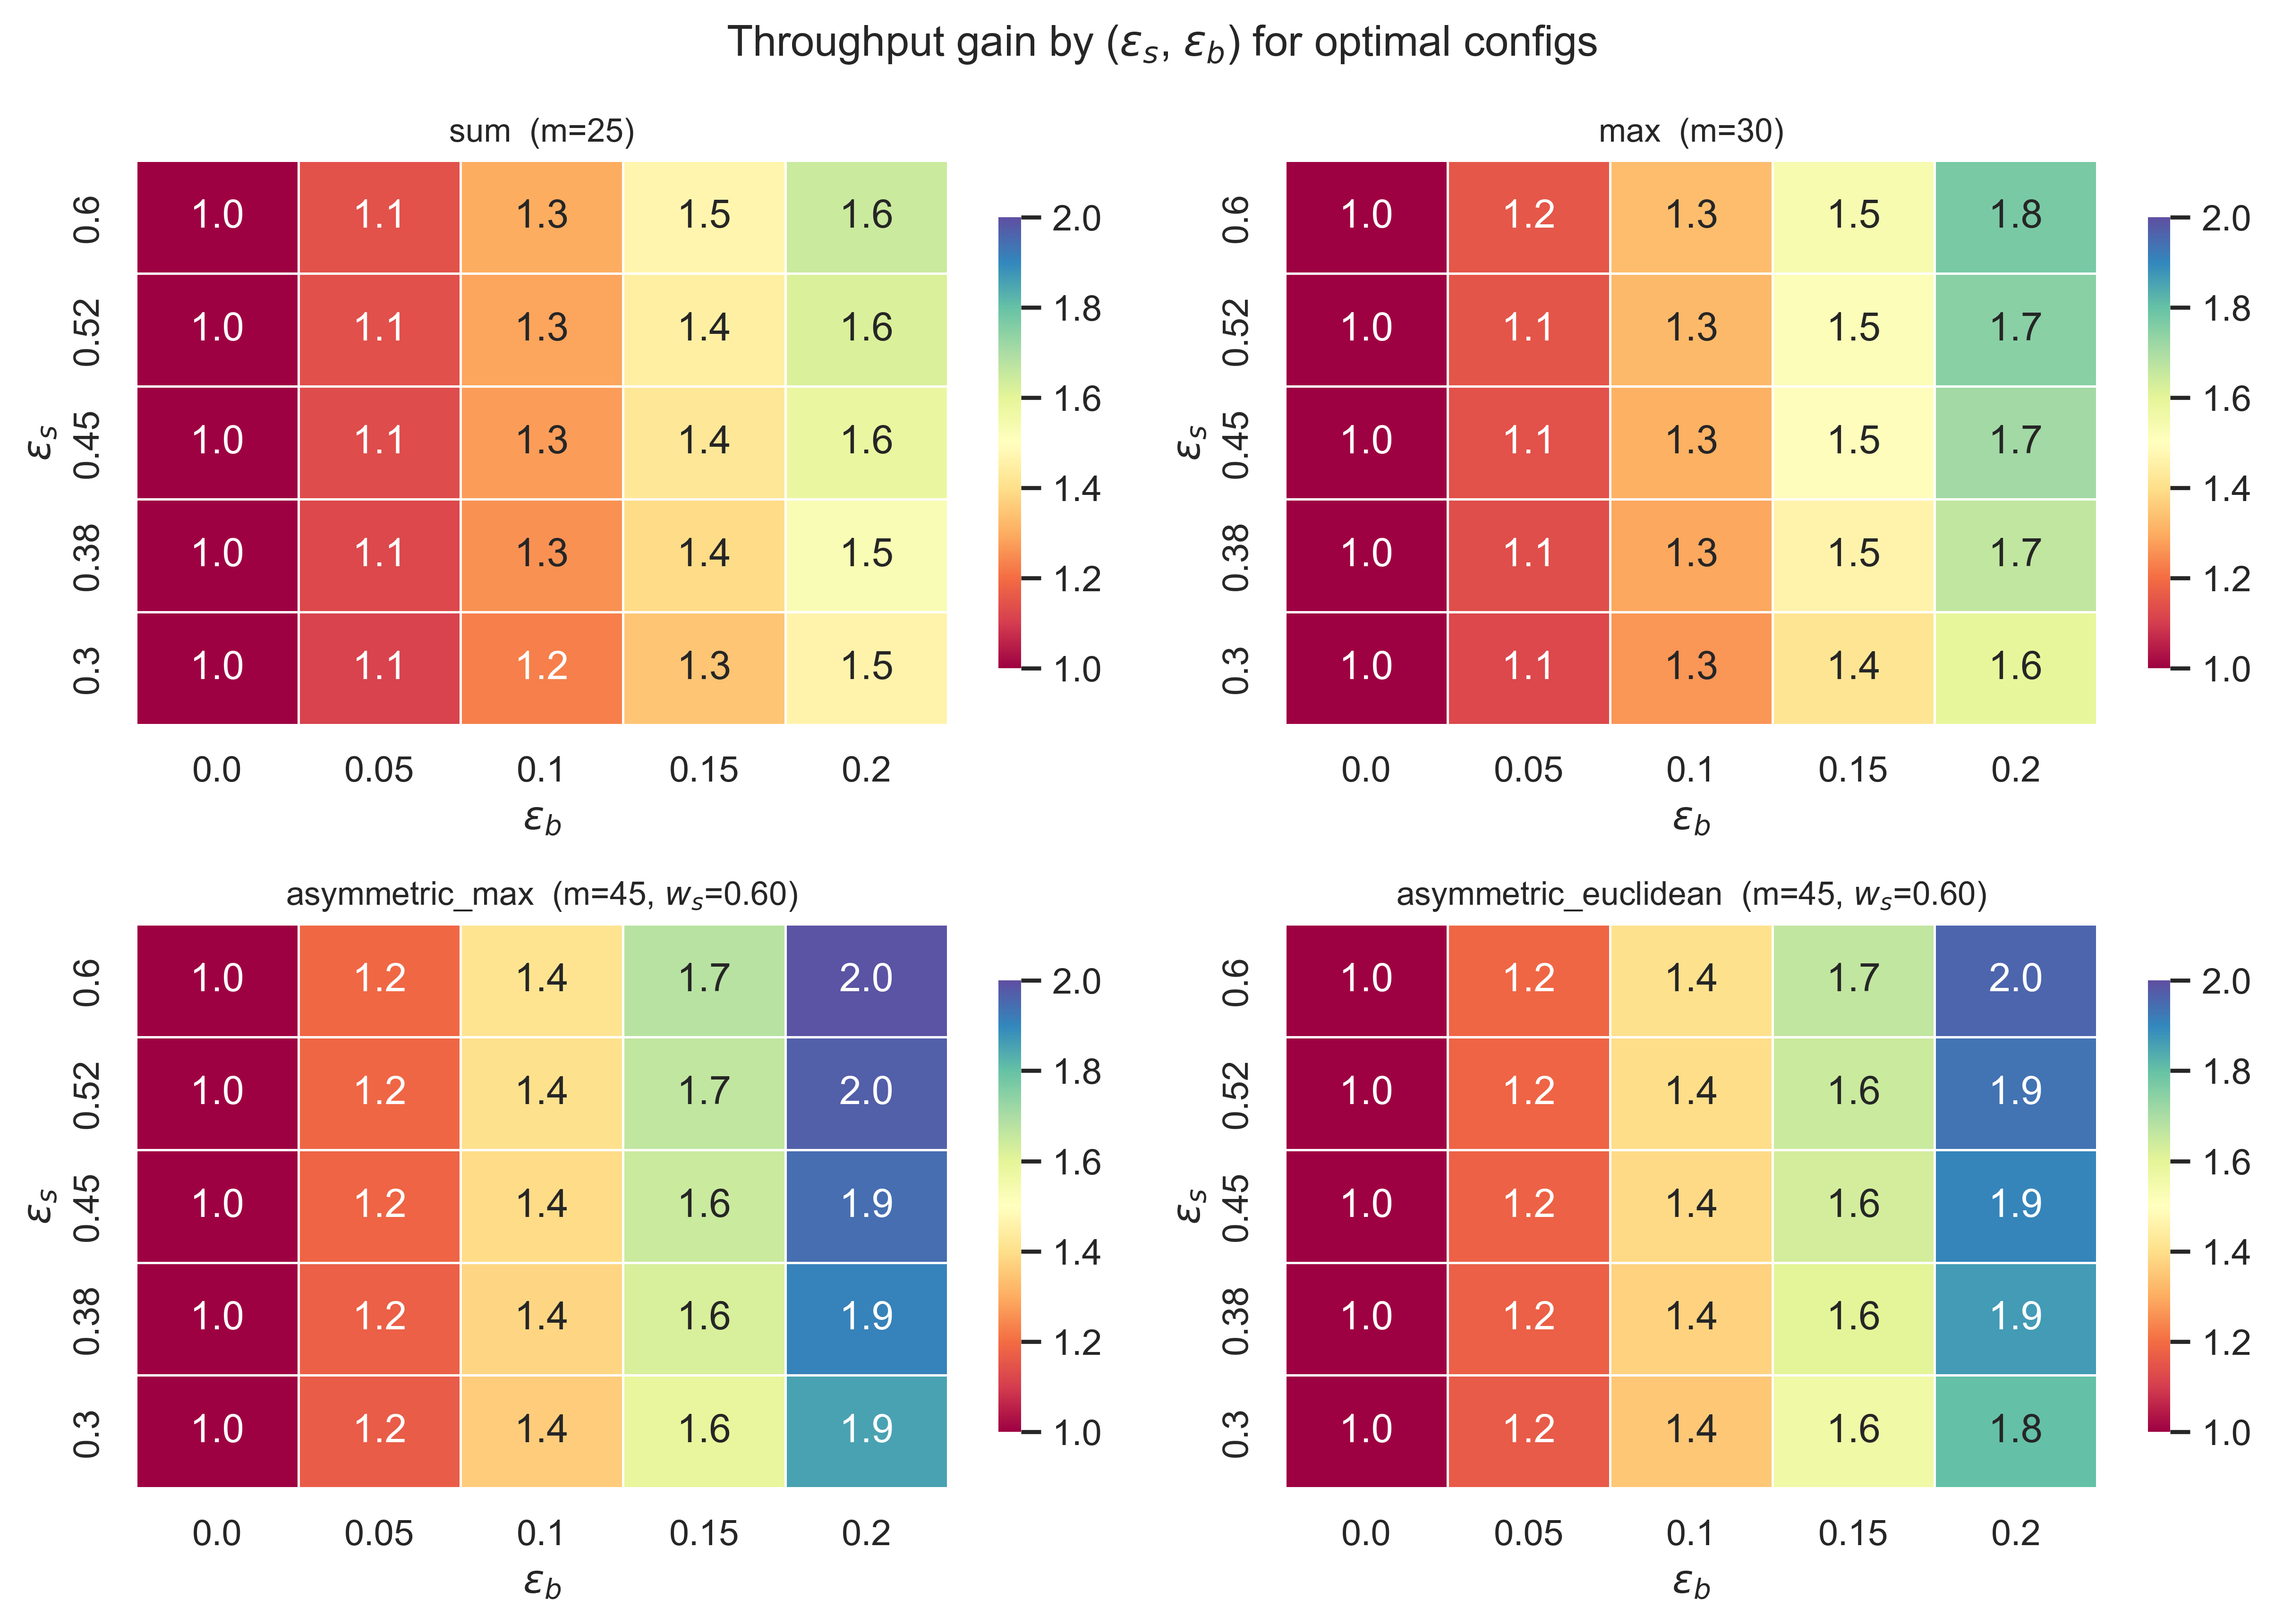

In [15]:
# --- Sensitivity heatmaps: throughput gain by (eps_s, eps_b) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for idx, agg in enumerate(agg_order):
    ax = axes[idx // 2, idx % 2]
    cfg = best_robust[best_robust["agg_function"] == agg].iloc[0]
    sub = optimal_detail[optimal_detail["agg_function"] == agg]

    pivot = sub.pivot_table(index="eps_s", columns="eps_b",
                            values="burst_throughput_gain").sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, cmap="Spectral", annot=True, fmt=".1f",vmin=1.0, vmax=2.0,
                linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8})

    title = f"{agg}  (m={int(cfg['m'])}"
    if agg.startswith("asymmetric"):
        title += f", $w_s$={cfg['w_s']:.2f}"
    title += ")"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$\\varepsilon_b$")
    ax.set_ylabel("$\\varepsilon_s$")

fig.suptitle("Throughput gain by ($\\varepsilon_s$, $\\varepsilon_b$) for optimal configs",
             fontsize=13)
plt.tight_layout()
our_file = os.path.join(our_dir, "robust_sensitivity_throughput.png")
plt.savefig(our_file, bbox_inches="tight", dpi=144)
plt.show()

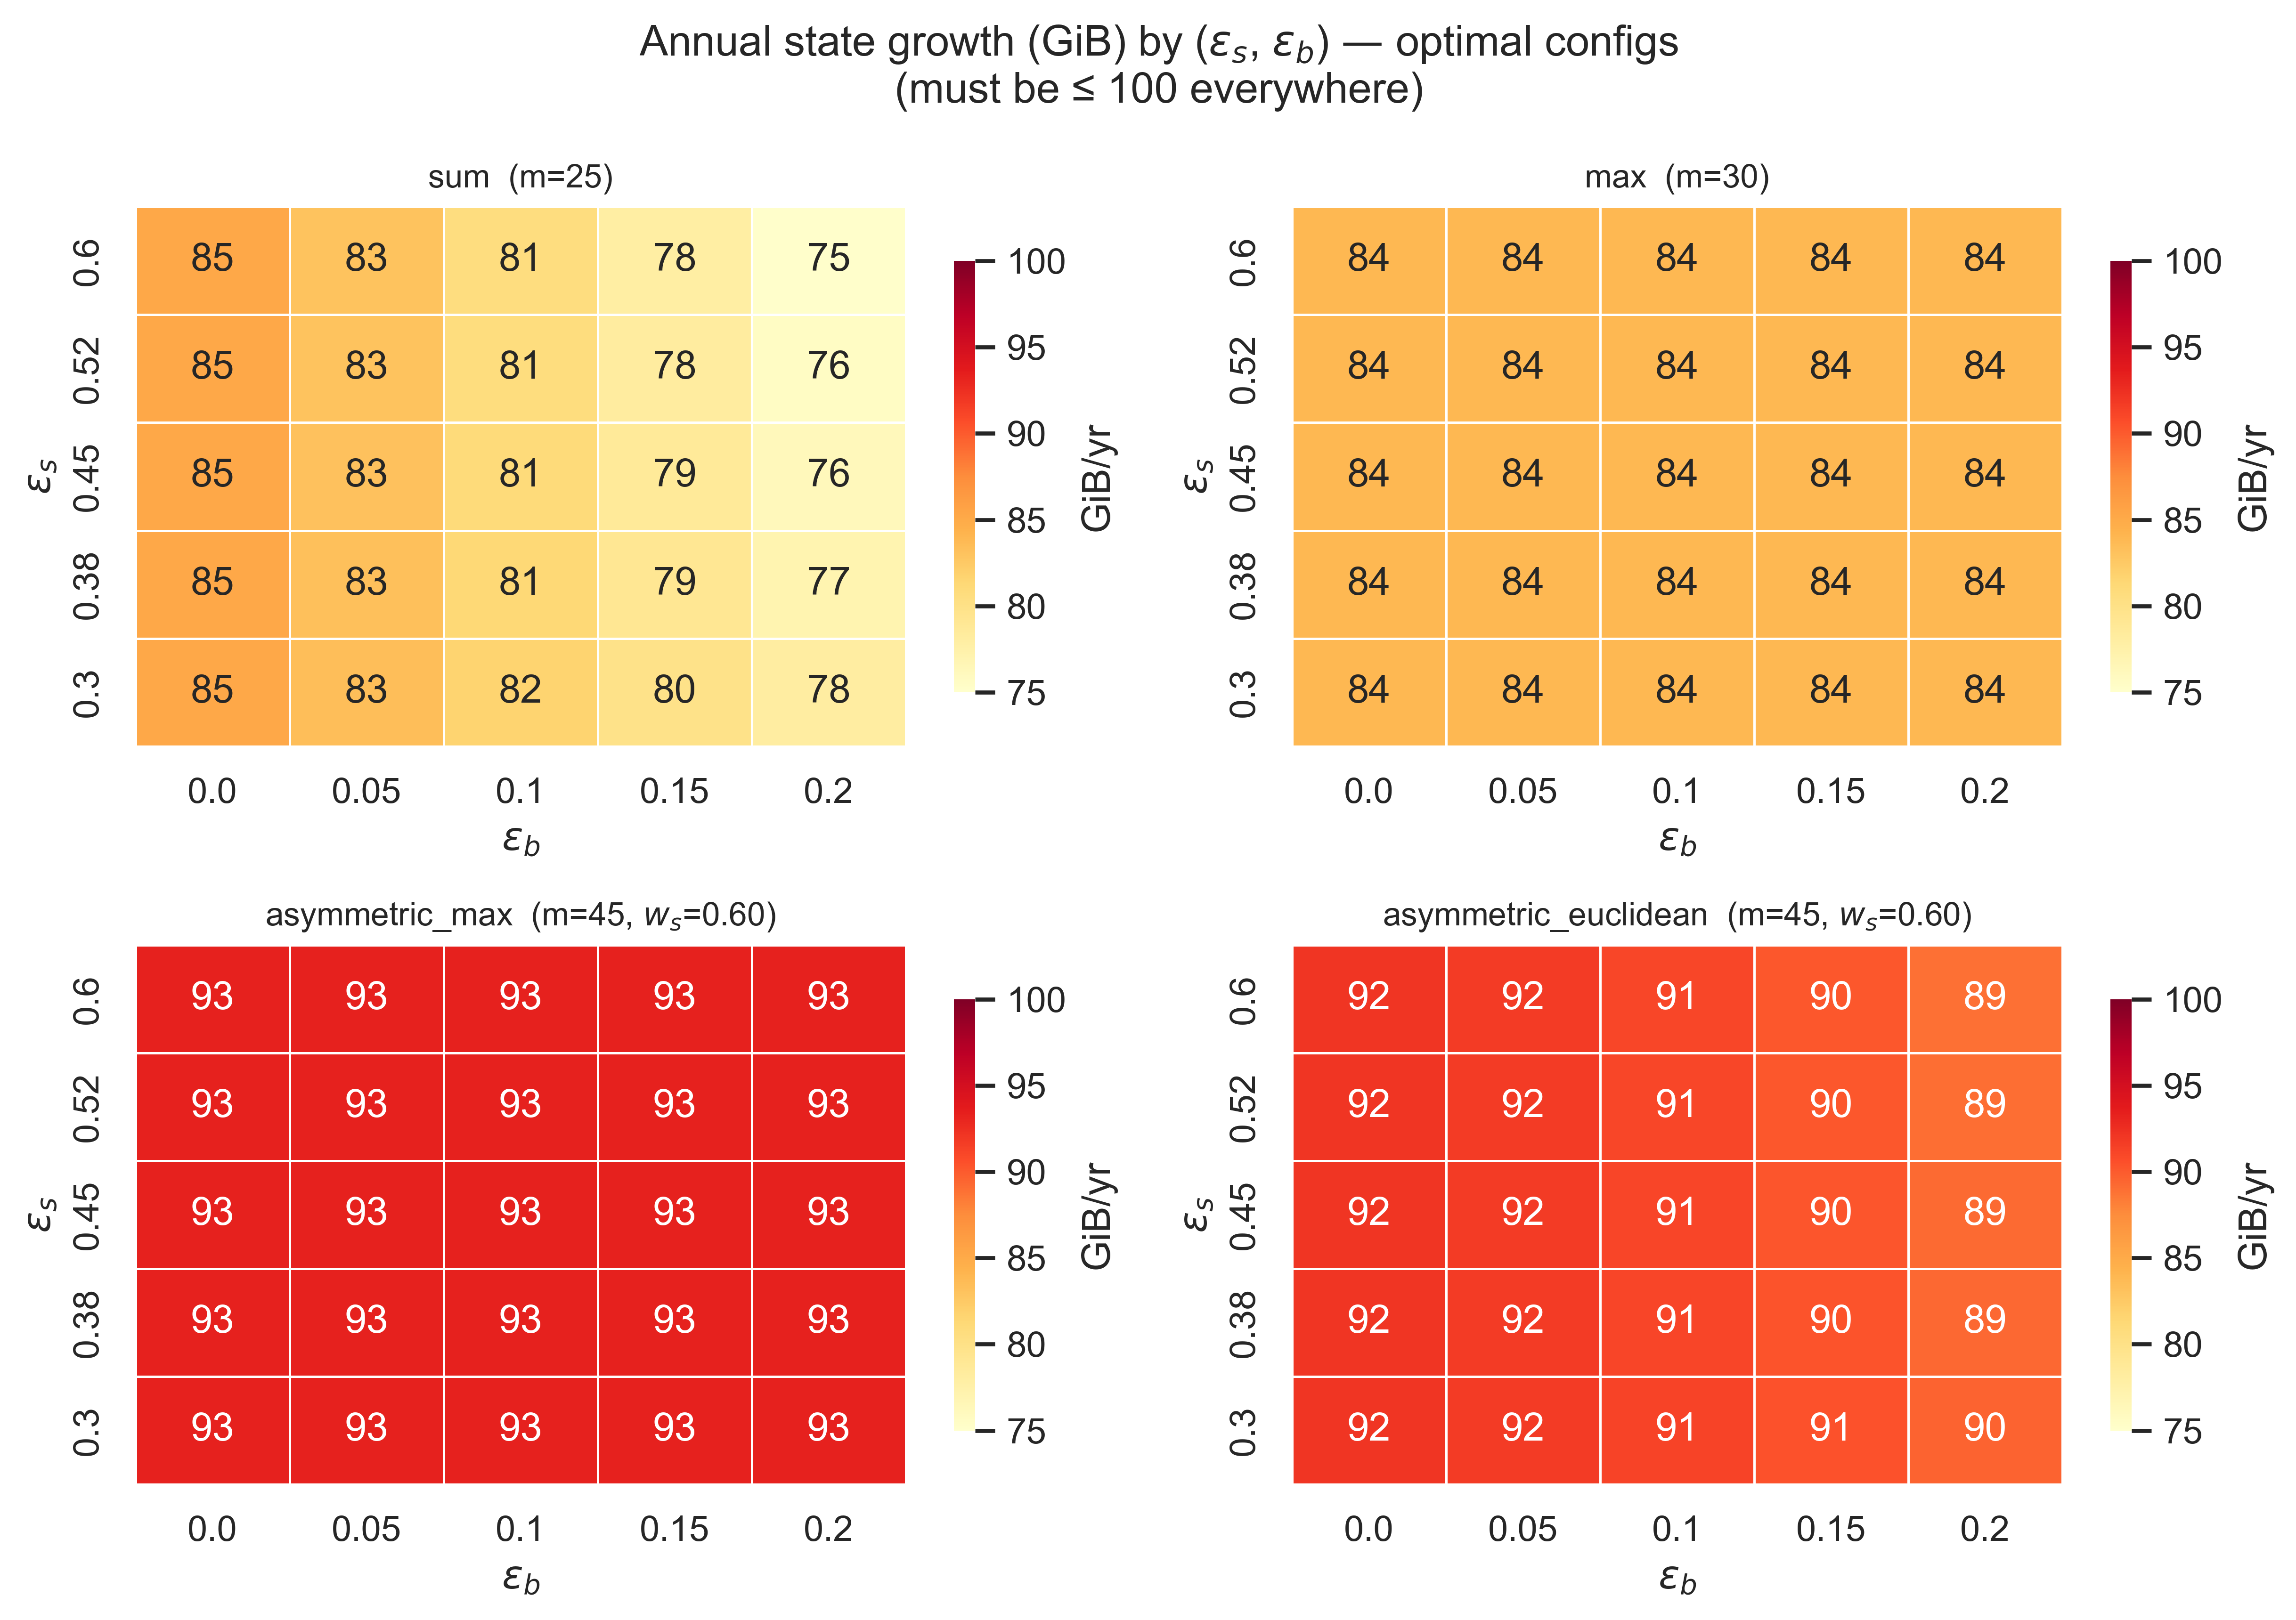

In [16]:
# --- Sensitivity heatmaps: state growth by (eps_s, eps_b) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for idx, agg in enumerate(agg_order):
    ax = axes[idx // 2, idx % 2]
    cfg = best_robust[best_robust["agg_function"] == agg].iloc[0]
    sub = optimal_detail[optimal_detail["agg_function"] == agg]

    pivot = sub.pivot_table(index="eps_s", columns="eps_b",
                            values="annual_state_growth_gib").sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
                linewidths=0.5, linecolor="white",vmin=75,
                vmax=STATE_GROWTH_CAP, cbar_kws={"shrink": 0.8, "label": "GiB/yr"})

    title = f"{agg}  (m={int(cfg['m'])}"
    if agg.startswith("asymmetric"):
        title += f", $w_s$={cfg['w_s']:.2f}"
    title += ")"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$\\varepsilon_b$")
    ax.set_ylabel("$\\varepsilon_s$")

fig.suptitle(
    f"Annual state growth (GiB) by ($\\varepsilon_s$, $\\varepsilon_b$) — optimal configs\n"
    f"(must be ≤ {STATE_GROWTH_CAP} everywhere)",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Effective price change for state and burst resources

Under EIP-8037, the effective price paid per unit of each resource depends on both the equilibrium base fee $b^*$ and the gas limit multiplier $m$:

- **Burst resource**: the gas cost per unit is $g_b^0$ (unchanged), so the effective price is $b^* \cdot g_b^0$. The price ratio relative to baseline ($m=1$) is simply $r^* = b^*/b^0$.
- **State resource**: the gas cost per state byte scales with $m$ (to fill the enlarged gas limit), so the effective price is $b^* \cdot m \cdot g_s^0$. The price ratio relative to baseline is $r^* \cdot m$.

This decomposition shows that even if the base fee drops ($r^* < 1$), the state operations can become *more expensive* overall because the gas cost multiplier $m$ dominates. This is exactly the mechanism by which state growth is constrained.

In [17]:
# Compute effective price ratios for optimal configurations
optimal_detail["effective_price_burst"] = optimal_detail["r_star"]         # b*/b_0
optimal_detail["effective_price_state"] = optimal_detail["r_star"] * optimal_detail["m"]  # (b*/b_0) * m

# Summary table: median effective price changes per aggregation function
price_summary = (
    optimal_detail
    .groupby("agg_function")
    .agg(
        m=("m", "first"),
        w_s=("w_s", "first"),
        median_r_star=("r_star", "median"),
        median_burst_price=("effective_price_burst", "median"),
        median_state_price=("effective_price_state", "median"),
        min_state_price=("effective_price_state", "min"),
        max_state_price=("effective_price_state", "max"),
    )
    .reset_index()
)
price_summary["median_r_star"] = price_summary["median_r_star"].round(3)
price_summary["median_burst_price"] = price_summary["median_burst_price"].round(3)
price_summary["median_state_price"] = price_summary["median_state_price"].round(2)
price_summary["min_state_price"] = price_summary["min_state_price"].round(2)
price_summary["max_state_price"] = price_summary["max_state_price"].round(2)

print("Effective price ratios for optimal robust configurations")
print("(ratio relative to baseline m=1, b=b_0)\n")
price_summary

Effective price ratios for optimal robust configurations
(ratio relative to baseline m=1, b=b_0)



,agg_function,m,w_s,median_r_star,median_burst_price,median_state_price,min_state_price,max_state_price
0,asymmetric_euclidean,45,0.6,0.038,0.038,1.70,1.46,2.35
1,asymmetric_max,45,0.6,0.036,0.036,1.62,1.44,2.06
2,max,30,0.4,0.068,0.068,2.05,1.71,2.93
3,sum,25,0.6,0.090,0.090,2.25,1.67,3.73


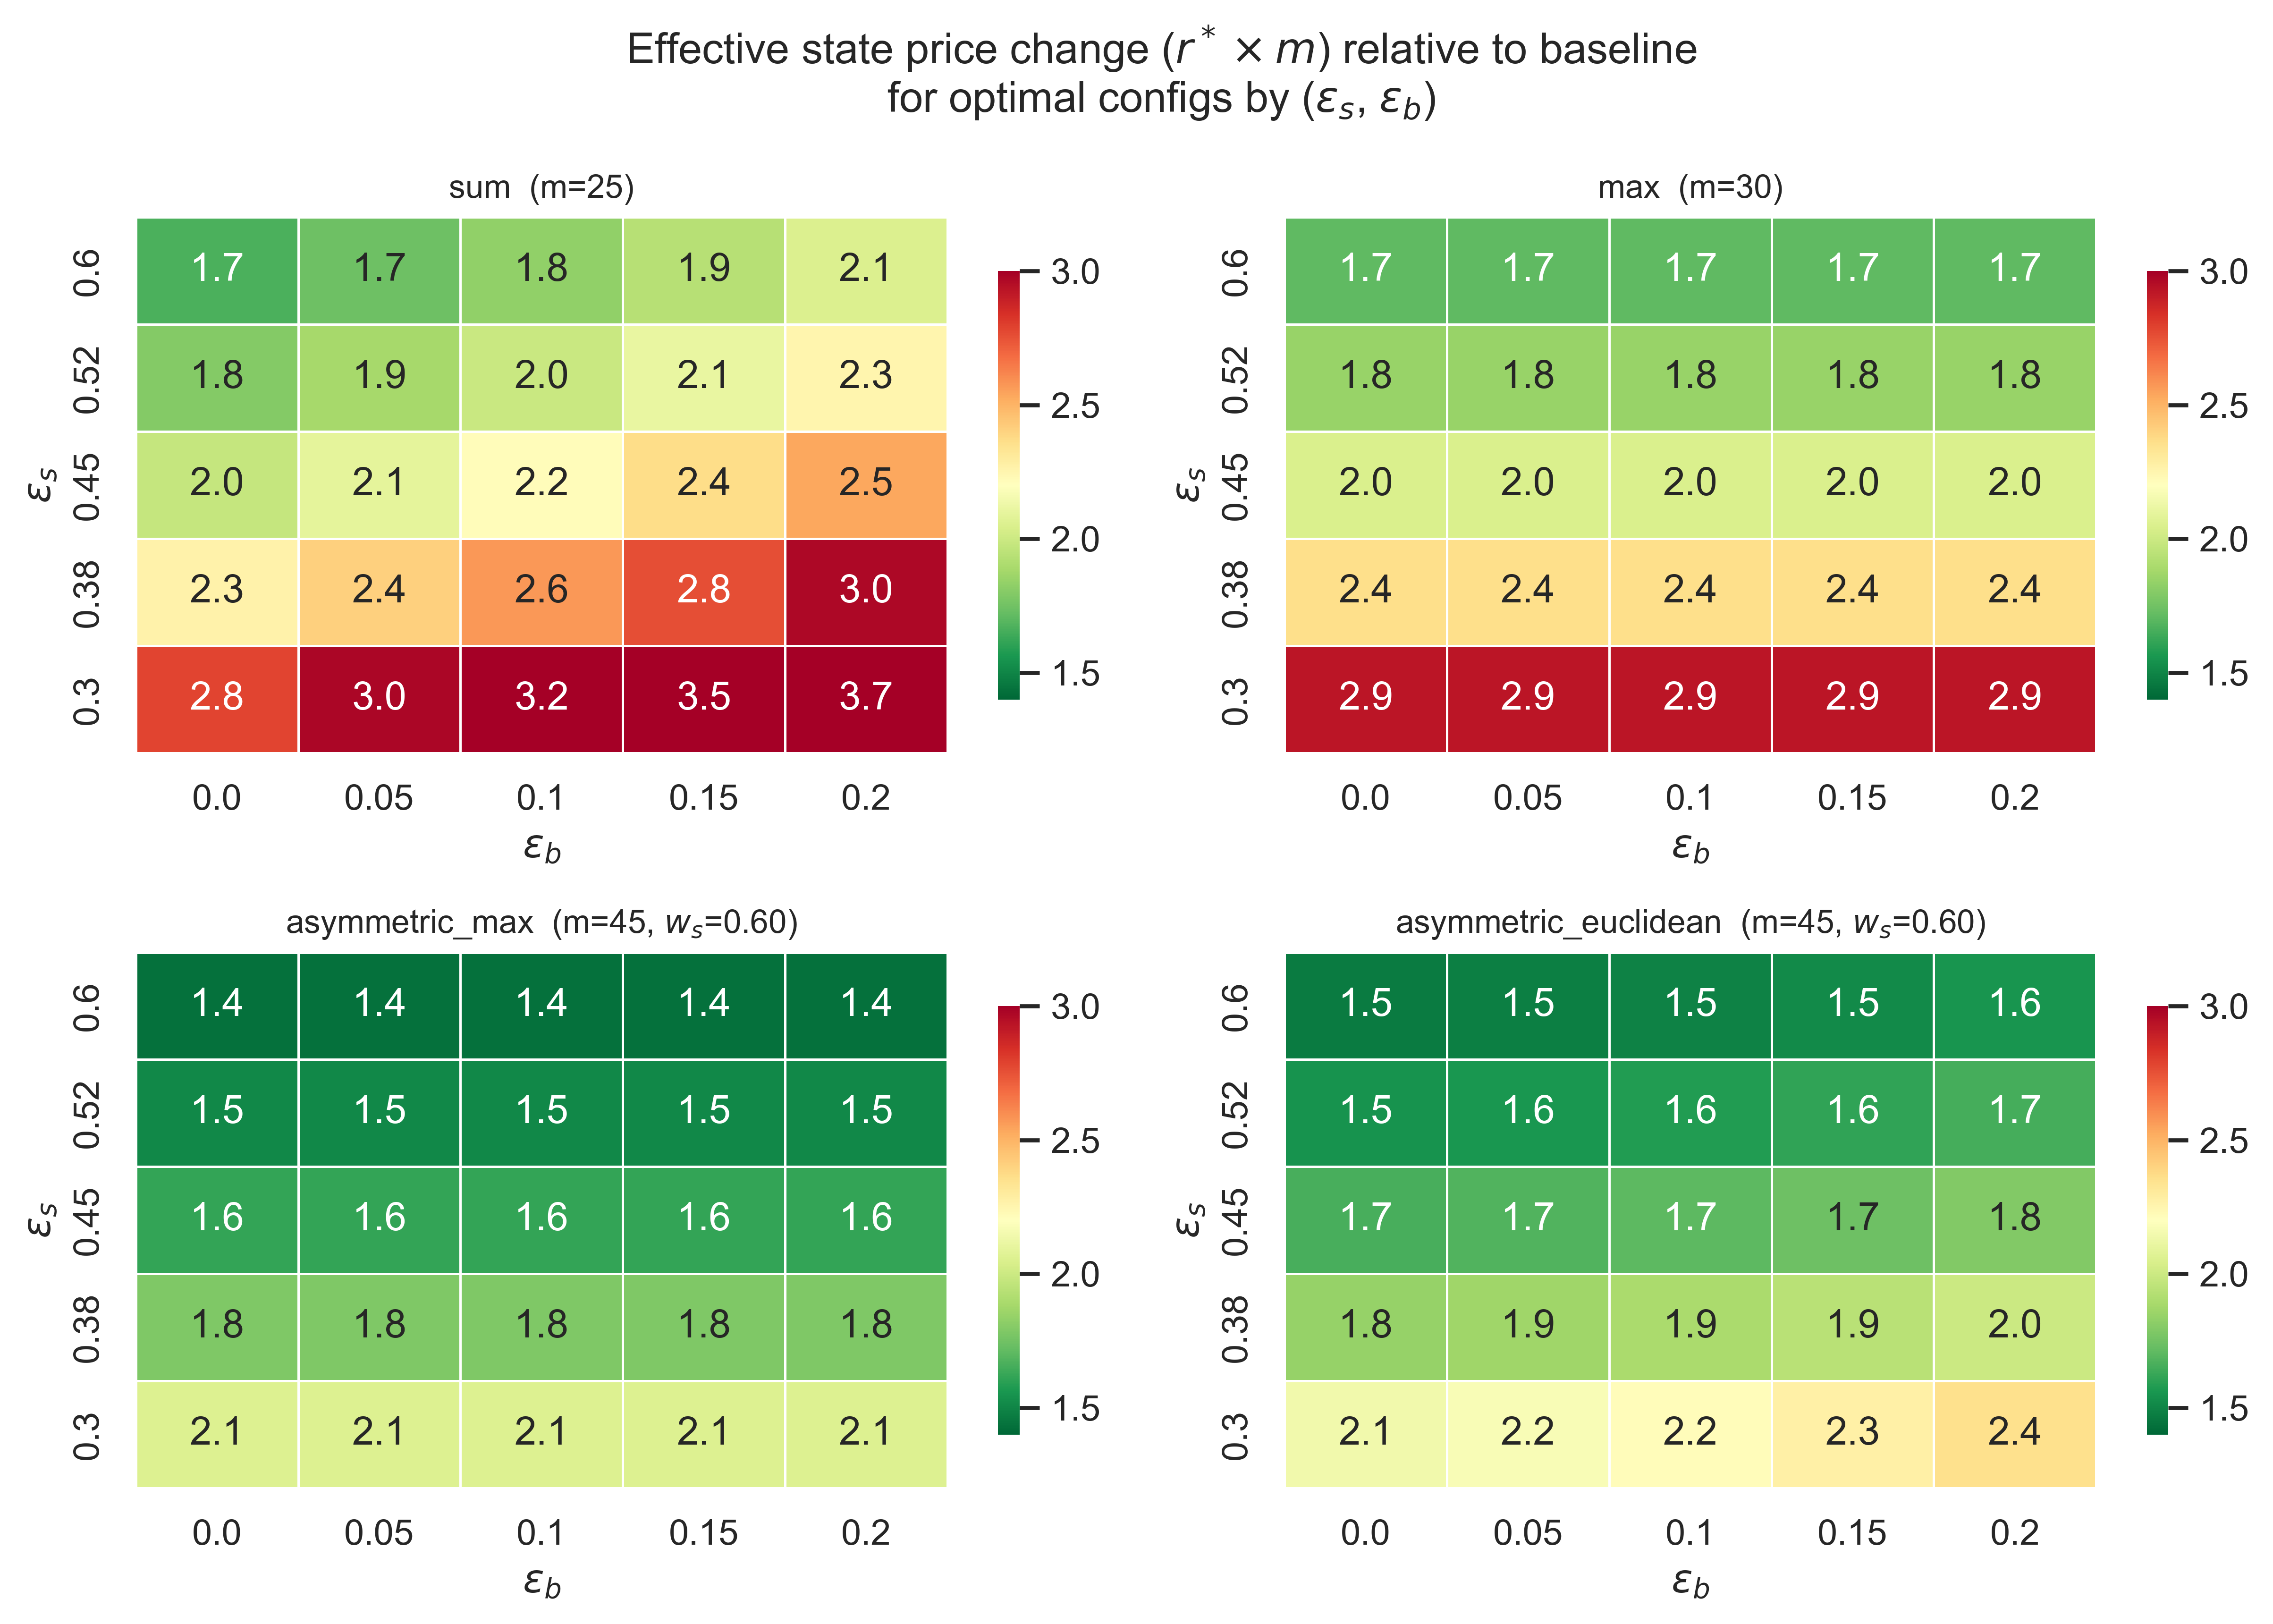

In [18]:
# --- Heatmaps: effective state price change by (eps_s, eps_b) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for idx, agg in enumerate(agg_order):
    ax = axes[idx // 2, idx % 2]
    cfg = best_robust[best_robust["agg_function"] == agg].iloc[0]
    sub = optimal_detail[optimal_detail["agg_function"] == agg]

    pivot = sub.pivot_table(index="eps_s", columns="eps_b",
                            values="effective_price_state").sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".1f",vmin=1.4, vmax=3,
                linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8})

    title = f"{agg}  (m={int(cfg['m'])}"
    if agg.startswith("asymmetric"):
        title += f", $w_s$={cfg['w_s']:.2f}"
    title += ")"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$\\varepsilon_b$")
    ax.set_ylabel("$\\varepsilon_s$")

fig.suptitle(
    "Effective state price change ($r^* \\times m$) relative to baseline\n"
    "for optimal configs by ($\\varepsilon_s$, $\\varepsilon_b$)",
    fontsize=13,
)
plt.tight_layout()
our_file = os.path.join(our_dir, "robust_effective_state_price.png")
plt.savefig(our_file, bbox_inches="tight", dpi=144)
plt.show()

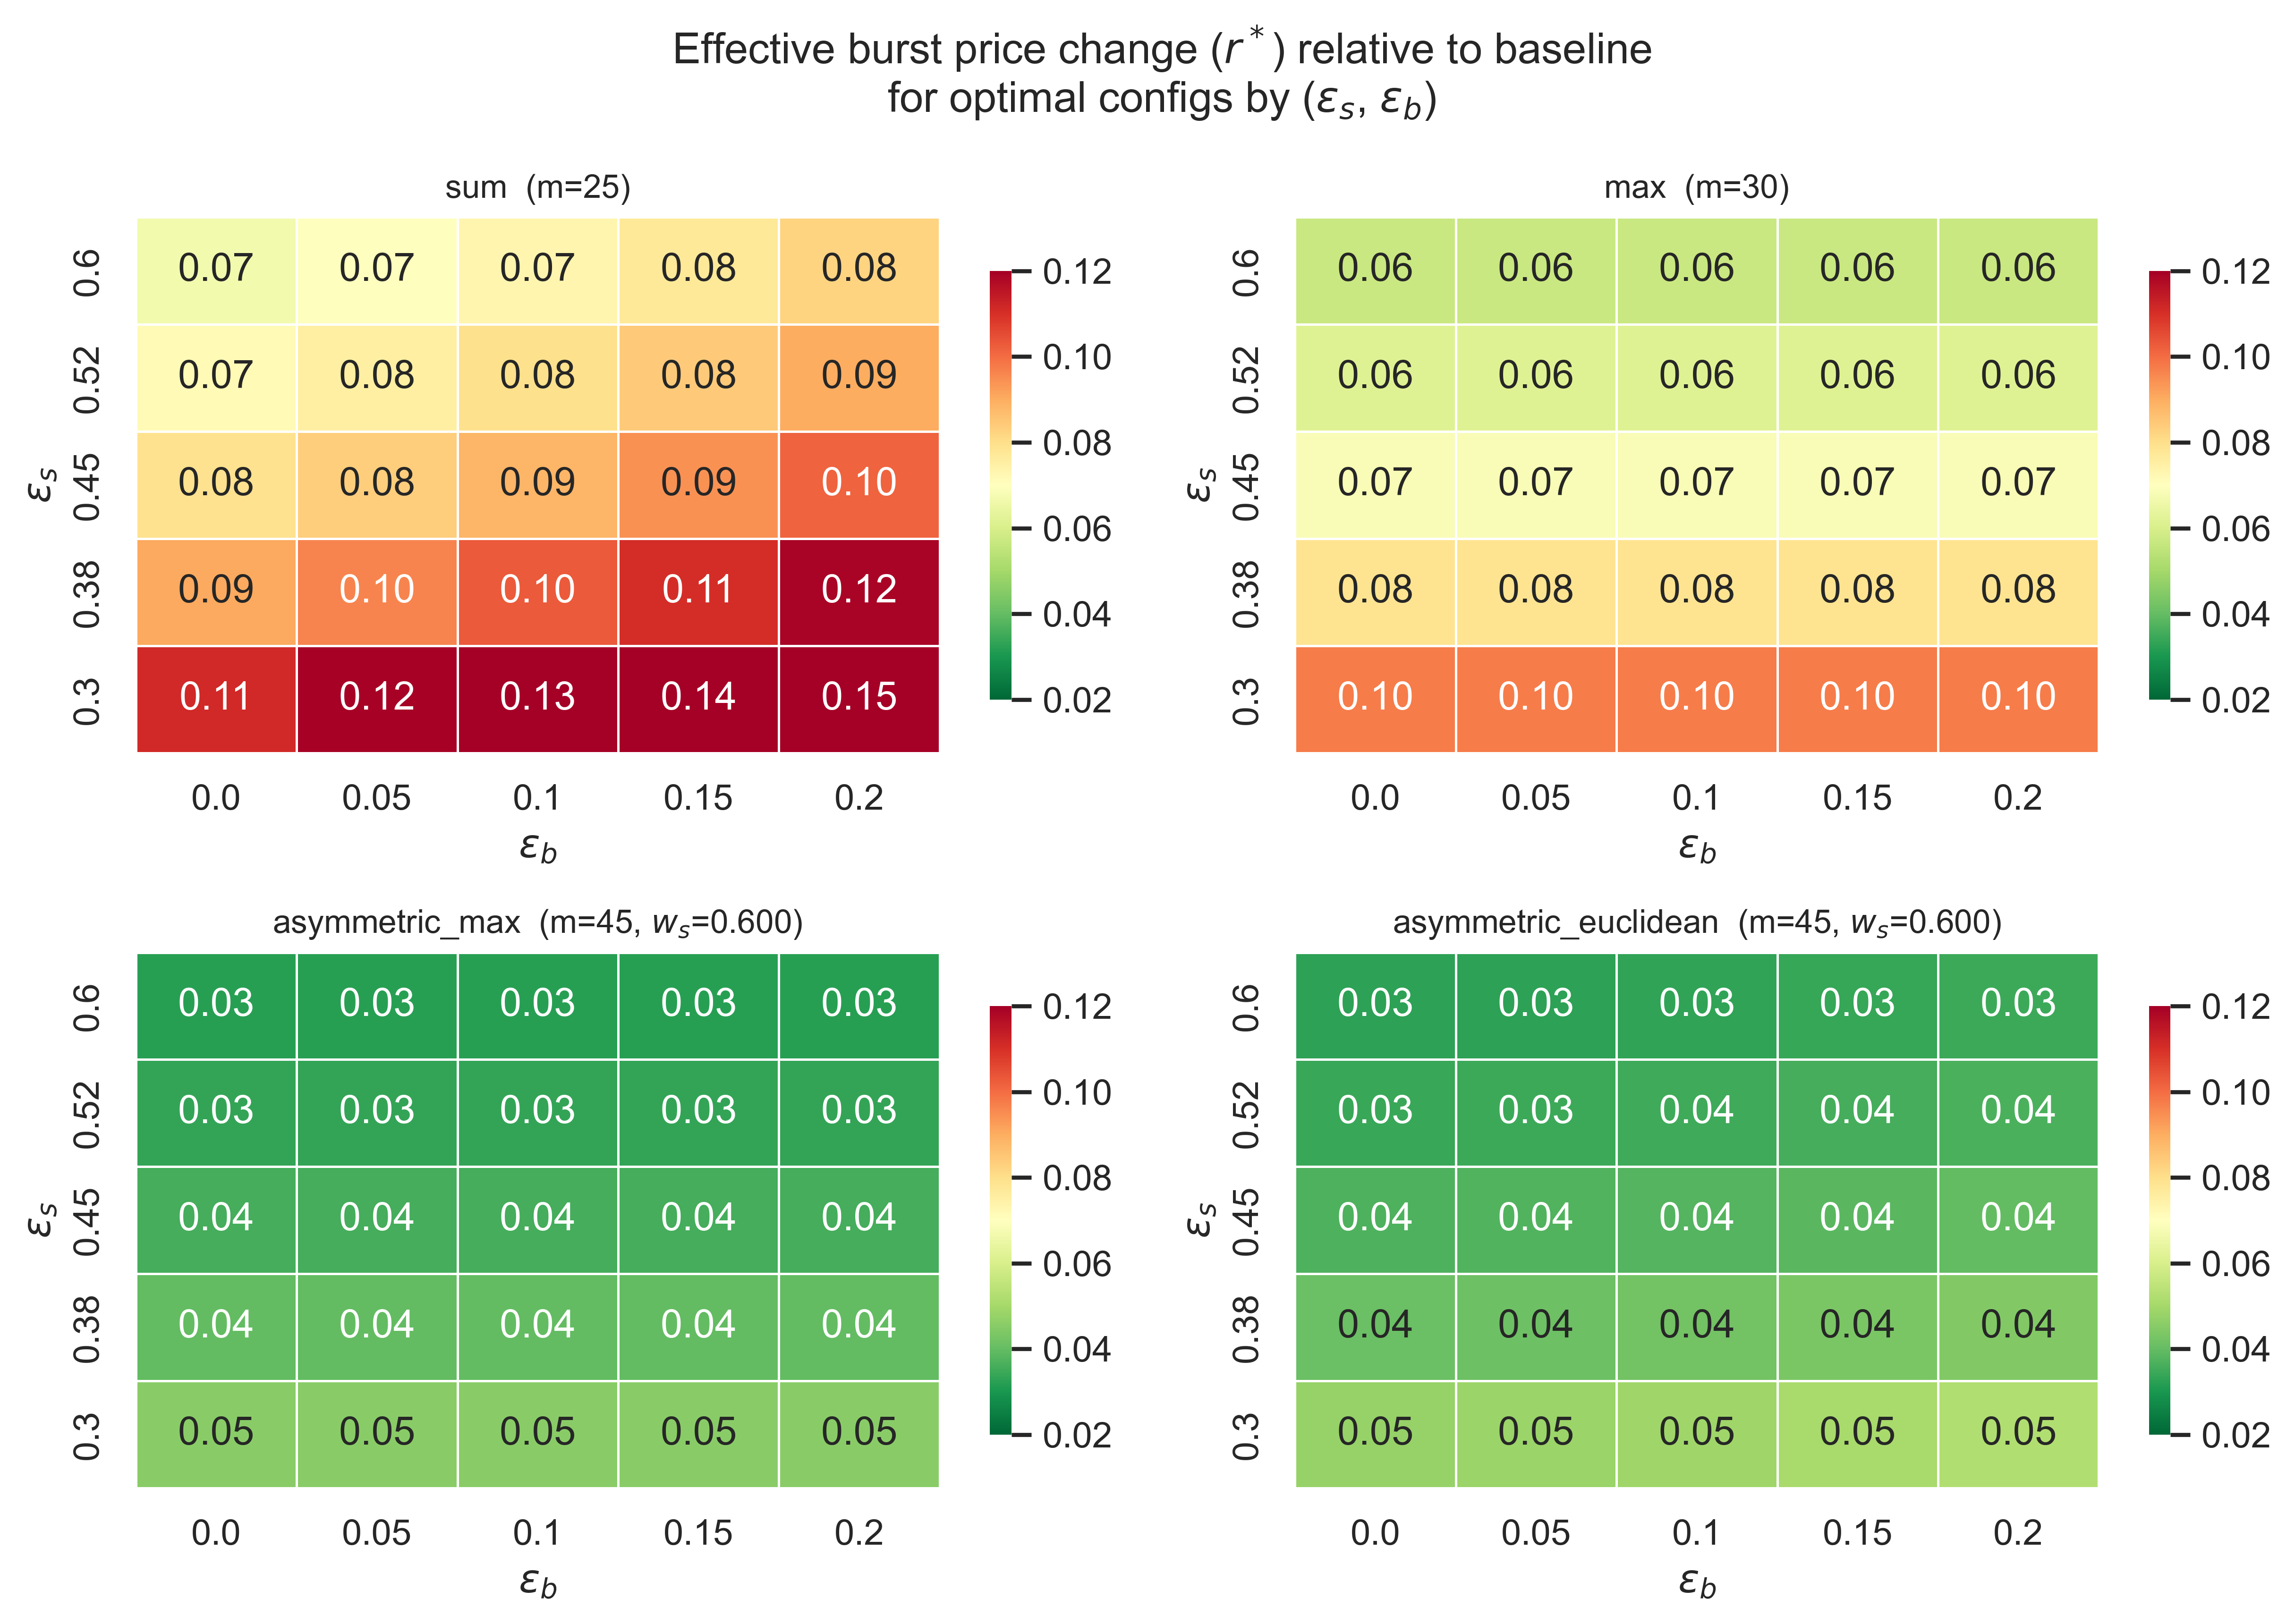

In [19]:
# --- Heatmaps: effective burst price change by (eps_s, eps_b) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for idx, agg in enumerate(agg_order):
    ax = axes[idx // 2, idx % 2]
    cfg = best_robust[best_robust["agg_function"] == agg].iloc[0]
    sub = optimal_detail[optimal_detail["agg_function"] == agg]

    pivot = sub.pivot_table(index="eps_s", columns="eps_b",
                            values="effective_price_burst").sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", annot=True, fmt=".2f",vmin=0.02, vmax=0.12,
                linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8})

    title = f"{agg}  (m={int(cfg['m'])}"
    if agg.startswith("asymmetric"):
        title += f", $w_s$={cfg['w_s']:.3f}"
    title += ")"
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("$\\varepsilon_b$")
    ax.set_ylabel("$\\varepsilon_s$")

fig.suptitle(
    "Effective burst price change ($r^*$) relative to baseline\n"
    "for optimal configs by ($\\varepsilon_s$, $\\varepsilon_b$)",
    fontsize=13,
)
plt.tight_layout()
plt.show()